# 1. Install Necessary Libraries

**Runtime:** Switch to a **GPU runtime** (Runtime → Change runtime type → T4 GPU) before running.
Unlike DBTL1–3 which used CPU-only sklearn/gensim, transformer fine-tuning is GPU-dependent.
On a T4, each epoch takes ~2–5 min depending on dataset size. On CPU it would take hours.

**Key new libraries:**
- `transformers` — Hugging Face model hub, Trainer API, tokenizers
- `datasets` — Hugging Face Dataset format required by Trainer
- `evaluate` — standardized metric computation
- `accelerate` — backend for Trainer's distributed/mixed-precision training

In [ ]:
!pip install -q --upgrade gspread transformers datasets evaluate accelerate scikit-learn pandas seaborn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 145.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 131.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 131.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 53.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 req

# 2. Authenticate and Access Google Drive + Sheets

In [ ]:
from google.colab import auth, drive
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

drive.mount('/content/drive')

import os
save_path = '/content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL4_Models_Results'
os.makedirs(save_path, exist_ok=True)
print(f"Drive ready. Saving to: {save_path}")

Mounted at /content/drive
Drive ready. Saving to: /content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL4_Models_Results


# 3. Import DBTL4 Datasets

DBTL4 uses the same preprocessed data as DBTL3 — one shared Train/Validate split and three
evaluation sets at different phishing prevalence proportions (50%, 5%, 1%).

The key difference from DBTL1–3 is the **model architecture**: instead of classical ML on
TF-IDF/Doc2Vec features, DBTL4 fine-tunes a pre-trained transformer directly on raw text.

In [ ]:
import pandas as pd

# --- DBTL4 Train/Validate ---
wb_dbtl4_tv = gc.open_by_url('https://docs.google.com/spreadsheets/d/1w8dP9OOaHrcc1LyZfE-k7Cn9wN60m0EiFZPD6jOG9GE/edit?usp=drive_link')
data_dbtl4_tv = wb_dbtl4_tv.get_worksheet(0).get_all_values()
df_dbtl4_train_valid = pd.DataFrame(data_dbtl4_tv[1:], columns=data_dbtl4_tv[0])

# --- DBTL4 Eval Sets (3 phishing prevalence thresholds) ---
wb_dbtl4_eval_50 = gc.open_by_url('https://docs.google.com/spreadsheets/d/1VwDnWLw9gLDfvNhVl1z4pIaEy7s0_MEStWZo9nuYKD4/edit?usp=drive_link')
data_dbtl4_eval_50 = wb_dbtl4_eval_50.get_worksheet(0).get_all_values()
df_dbtl4_eval_50 = pd.DataFrame(data_dbtl4_eval_50[1:], columns=data_dbtl4_eval_50[0])

wb_dbtl4_eval_5 = gc.open_by_url('https://docs.google.com/spreadsheets/d/1XfD7MHfxCC-C1QncX2tEQ-TnDSwEL97GyTaKMdD0I0w/edit?usp=drive_link')
data_dbtl4_eval_5 = wb_dbtl4_eval_5.get_worksheet(0).get_all_values()
df_dbtl4_eval_5 = pd.DataFrame(data_dbtl4_eval_5[1:], columns=data_dbtl4_eval_5[0])

wb_dbtl4_eval_1 = gc.open_by_url('https://docs.google.com/spreadsheets/d/1W13mNJYEzwJlHVUiJ5ux28kvFf-hbOLyKtFn676sCx8/edit?usp=drive_link')
data_dbtl4_eval_1 = wb_dbtl4_eval_1.get_worksheet(0).get_all_values()
df_dbtl4_eval_1 = pd.DataFrame(data_dbtl4_eval_1[1:], columns=data_dbtl4_eval_1[0])

print(f"DBTL4 Train/Valid : {len(df_dbtl4_train_valid)} rows")
print(f"DBTL4 Eval (50)   : {len(df_dbtl4_eval_50)} rows")
print(f"DBTL4 Eval (5)    : {len(df_dbtl4_eval_5)} rows")
print(f"DBTL4 Eval (1)    : {len(df_dbtl4_eval_1)} rows")
print(f"\nColumns: {list(df_dbtl4_train_valid.columns)}")
print(f"Label distribution (train/valid):\n{df_dbtl4_train_valid['label_specific'].value_counts()}")

DBTL4 Train/Valid : 3200 rows
DBTL4 Eval (50)   : 800 rows
DBTL4 Eval (5)    : 421 rows
DBTL4 Eval (1)    : 404 rows

Columns: ['text', 'label_specific', 'label_generic']
Label distribution (train/valid):
label_specific
llm_phishing      800
llm_legit         800
human_legit       800
human_phishing    800
Name: count, dtype: int64


# 4. Data Preparation

### Label column: `label_specific`
`label_specific` for the 4-class labels. We map it to integers and store in a new `labels` column.

**Why `labels` (plural)?** The Hugging Face `Trainer` looks for a key named `labels` in each
batch to compute loss. Using `label` (singular) can silently fail in some versions.

<br>

### Train/Val split: stratified 80/20
Stratification ensures each class is proportionally represented in both splits.
Without it, rare classes could be underrepresented in validation.

<br>

### Why not use the existing eval sets for validation?
The eval sets are held out for final unbiased evaluation — using them during training
(even just to monitor loss) would introduce leakage into model selection decisions.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

# Map string labels → integers
# NOTE: if your label_specific values differ from these, update the mapping below.
LABEL_MAPPING = {
    'human_legit':      0,
    'llm_legit':        1,
    'human_phishing':   2,
    'llm_phishing':     3
}
ID2LABEL = {v: k for k, v in LABEL_MAPPING.items()}

# For custom cost: which classes are 'phishing' in the binary sense?
PHISHING_CLASSES = {2, 3}  # human_phishing and llm_phishing

def prepare_df(df, label_col='label_specific'):
    """Map labels, keep only required columns, drop rows with unmapped labels."""
    out = df[['text', label_col]].copy()
    out['labels'] = out[label_col].map(LABEL_MAPPING)
    n_unmapped = out['labels'].isna().sum()
    if n_unmapped > 0:
        print(f"  WARNING: {n_unmapped} rows had unrecognized labels and were dropped.")
        out = out.dropna(subset=['labels'])
    out['labels'] = out['labels'].astype(int)
    return out[['text', 'labels']]

df_tv_prepared = prepare_df(df_dbtl4_train_valid)

# Stratified 80/20 split
df_train, df_val = train_test_split(
    df_tv_prepared, test_size=0.2, random_state=42,
    stratify=df_tv_prepared['labels']
)

# Prepare all 3 eval sets
df_eval_50 = prepare_df(df_dbtl4_eval_50)
df_eval_5  = prepare_df(df_dbtl4_eval_5)
df_eval_1  = prepare_df(df_dbtl4_eval_1)

# Convert to HuggingFace Datasets
dataset = DatasetDict({
    'train':      Dataset.from_pandas(df_train,   preserve_index=False),
    'validation': Dataset.from_pandas(df_val,     preserve_index=False),
    'eval_50':    Dataset.from_pandas(df_eval_50, preserve_index=False),
    'eval_5':     Dataset.from_pandas(df_eval_5,  preserve_index=False),
    'eval_1':     Dataset.from_pandas(df_eval_1,  preserve_index=False),
})

print(dataset)
print(f"\nTrain label distribution: {dict(pd.Series(df_train['labels']).value_counts().sort_index())}")
print(f"Val   label distribution: {dict(pd.Series(df_val['labels']).value_counts().sort_index())}")

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 2560
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 640
    })
    eval_50: Dataset({
        features: ['text', 'labels'],
        num_rows: 800
    })
    eval_5: Dataset({
        features: ['text', 'labels'],
        num_rows: 421
    })
    eval_1: Dataset({
        features: ['text', 'labels'],
        num_rows: 404
    })
})

Train label distribution: {0: np.int64(640), 1: np.int64(640), 2: np.int64(640), 3: np.int64(640)}
Val   label distribution: {0: np.int64(160), 1: np.int64(160), 2: np.int64(160), 3: np.int64(160)}


# 5. Tokenization + Model Selection

### Transformer Model Candidates for DBTL4

| Model | Size | Speed | Notes |
|---|---|---|---|
| `distilbert-base-uncased` | 66M | ~2× faster than BERT | Current default — good starting point |
| `roberta-base` | 125M | baseline | Trained on more data with better masking strategy; consistently 1–3% better than BERT on classification |
| `roberta-large` | 355M | ~2× slower than BERT | Stronger than roberta-base but may hit OOM on T4 at batch_size=16; drop to 8 or use `adamw_8bit` |
| `microsoft/deberta-v3-small` | 142M | ~1.5× slower than BERT | State-of-the-art on most classification benchmarks; better than RoBERTa on imbalanced tasks |
| `microsoft/deberta-v3-base` | 184M | ~2× slower than BERT | Best accuracy-per-parameter of any encoder; worth trying if T4 memory allows |
| `google/electra-small-discriminator` | 14M | ~4× faster than BERT | Tiny but surprisingly strong; good for rapid iteration |
| `google/electra-base-discriminator` | 110M | ~1× (same as BERT) | Better than BERT-base at same size due to replaced token detection objective |
| `typeform/distilroberta-base-v2` | 82M | ~2× faster than BERT | DistilRoBERTa — best of both worlds if speed matters |
| `bert-base-uncased` | 110M | baseline | The original — included for completeness but strictly dominated by RoBERTa |
| `albert-base-v2` | 12M | ~1.7× faster than BERT | Parameter-sharing makes it tiny; accuracy roughly on par with BERT-base |
| `cybersectony/phishing-email-detection-distilbert_v2.4.1` | 66M | ~2× faster than BERT | Already fine-tuned on phishing emails — strongest zero-shot baseline; fine-tune further for best results |
| `ealvaradob/bert-finetuned-phishing` | 110M | baseline | Another phishing-specific fine-tune on BERT-base; useful as a second domain-adapted baseline |

<br>

**Default: `distilbert-base-uncased`** — fast enough to iterate, strong enough to be meaningful.
Swap `MODEL_CHECKPOINT` to `"roberta-base"` for a final high-quality run.

<br>

### Padding strategy: dynamic (not max_length)
Tokenize with `truncation=True` only, then use `DataCollatorWithPadding`
to pad each batch only to the length of its longest sequence. This reduces memory usage
significantly and speeds up training.

In [ ]:
from transformers import AutoTokenizer, DataCollatorWithPadding

MODEL_CHECKPOINT = "cybersectony/phishing-email-detection-distilbert_v2.4.1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_function(examples):
    # truncation=True: silently cuts off anything beyond 512 tokens.
    # No padding here — DataCollatorWithPadding handles it per-batch.
    return tokenizer(examples["text"], truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# DataCollatorWithPadding pads each batch to its own max length (dynamic padding)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"Tokenized dataset: {tokenized_datasets}")
print(f"\nSample token lengths in training set:")
lengths = [len(x) for x in tokenized_datasets['train']['input_ids'][:200]]
print(f"  Min: {min(lengths)}, Max: {max(lengths)}, Mean: {np.mean(lengths):.0f}")
print(f"  (If mean << 512, dynamic padding is saving significant compute)")

Map:   0%|          | 0/2560 [00:00<?, ? examples/s]

Map:   0%|          | 0/640 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/421 [00:00<?, ? examples/s]

Map:   0%|          | 0/404 [00:00<?, ? examples/s]

Tokenized dataset: DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2560
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 640
    })
    eval_50: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 800
    })
    eval_5: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 421
    })
    eval_1: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 404
    })
})

Sample token lengths in training set:
  Min: 36, Max: 512, Mean: 190
  (If mean << 512, dynamic padding is saving significant compute)


# 6. Metrics and Pre-Trained Model Setup

**During training:** F1-macro + accuracy (cheap to compute, available from logits).

**At final evaluation:** Full suite — F1, ROC-AUC, AUC-PR, Custom Cost — consistent with
the rest of the DBTL series.

In [ ]:
import evaluate
from transformers import AutoModelForSequenceClassification

accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1  = f1_metric.compute(predictions=predictions, references=labels, average='macro')
    return {**acc, **f1}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=4,
    id2label=ID2LABEL,
    label2id=LABEL_MAPPING,
    ignore_mismatched_sizes=True  # avoids warning when replacing classification head
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_CHECKPOINT}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model: cybersectony/phishing-email-detection-distilbert_v2.4.1
Total parameters:     66,956,548
Trainable parameters: 66,956,548


# 7. Fine Tuning Configuration

### Key changes from starter code, and why:

| Setting | DBTL4 | Reason |
|---|---|---|
| `metric_for_best_model` |  `f1` | F1 is more meaningful than accuracy here |
| `fp16` |  `True` | ~2× speedup on T4 GPU, minimal accuracy loss |
| `lr_scheduler_type` | `cosine` | Smoother LR decay, often better final performance |
| `num_train_epochs` | `6` | With early stopping (patience=2), more epochs = safety net |
| `report_to` |  `none` | Suppresses wandb prompts in Colab |
| `save_total_limit` |  `2` | Only keeps 2 checkpoints to save Drive space |
| EarlyStopping |  patience=2 | Stops if val F1 doesn't improve for 2 epochs |

<br>
<br>

### On learning rate (2e-5):
2e-5 is the standard starting point for fine-tuning BERT-family models. Too high (>5e-5)
causes catastrophic forgetting of pre-trained weights; too low (<1e-5) converges slowly.
If you see loss oscillation, try 1e-5.

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

checkpoint_dir = os.path.join(save_path, 'checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)

training_args = TrainingArguments(
    output_dir=checkpoint_dir,

    # --- Optimizer ---
    learning_rate=2e-5,
    weight_decay=0.01,              # L2 regularization on all non-bias weights
    lr_scheduler_type='cosine',     # Smoother decay than default linear
    optim="adamw_torch",            # AdamW with PyTorch backend [default anyways]

    # --- Batch / Epochs ---
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,  # Larger eval batch: no gradients, less memory
    num_train_epochs=6,             # Early stopping will cut this short if needed

    # --- Evaluation + Checkpointing ---
    eval_strategy='epoch',
    save_strategy='epoch',
    metric_for_best_model='f1',     # Use F1-macro, not accuracy
    greater_is_better=True,
    load_best_model_at_end=True,    # Restore best checkpoint after training
    save_total_limit=2,             # Only keep the 2 most recent checkpoints

    # --- Speed / Logging ---
    fp16=True,                      # Mixed precision — requires GPU
    report_to='none',               # Suppress wandb / other trackers
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Trainer configured. Ready to train.")

Trainer configured. Ready to train.


# 8. Supervised Fine Tuning

In [ ]:
print("Starting training...")
train_result = trainer.train()

print("\n--- Training Summary ---")
print(f"  Total steps:       {train_result.global_step}")
print(f"  Training loss:     {train_result.training_loss:.4f}")
print(f"  Training time:     {train_result.metrics['train_runtime']:.0f}s")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.160567,0.173911,0.968750,0.968862
2,0.048706,0.023638,0.990625,0.990653
3,0.017311,0.020030,0.990625,0.990625
4,0.017337,0.013092,0.995313,0.995312
5,0.011022,0.013191,0.995313,0.995312
6,0.000268,0.009607,0.998437,0.998437


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



--- Training Summary ---
  Total steps:       960
  Training loss:     0.2978
  Training time:     260s


# 9. Save Model Assets to Drive

In [ ]:
model_save_path = os.path.join(save_path, 'best_model')
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"Model and tokenizer saved to: {model_save_path}")
print("\nTo reload later:")
print(f'  from transformers import pipeline')
print(f'  clf = pipeline("text-classification", model="{model_save_path}")')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: /content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL4_Models_Results/best_model

To reload later:
  from transformers import pipeline
  clf = pipeline("text-classification", model="/content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL4_Models_Results/best_model")


# 10. Evaluation

## 10.1. Custom Cost Function

Consistent with DBTL1–3:
`Cost = (15 × False Negatives) + False Positives`

In the 4-class setting, FN/FP are computed by collapsing predictions back to binary
(`phishing_human` and `phishing_llm` → phishing=1, the rest → legit=0).

## 10.2. ROC-AUC and AUC-PR
These require class probabilities (softmax of logits), not hard predictions.
Both are computed OVR macro-averaged for multi-class, consistent with DBTL3.

In [ ]:
import numpy as np
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

def calculate_custom_cost(y_true_bin, y_pred_bin):
    """
    Cost = (50 * False Negatives) + False Positives
    Inputs are binary arrays: phishing=1, legit=0
    """
    y_true_bin = np.array(y_true_bin)
    y_pred_bin = np.array(y_pred_bin)
    fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    return int(50 * fn + fp)

def to_binary(labels):
    """Collapse 4-class labels to binary: phishing classes (2,3) → 1, legit (0,1) → 0."""
    return np.array([1 if l in PHISHING_CLASSES else 0 for l in labels])

def evaluate_split(split_name, tokenized_split):
    """Run full evaluation on one eval split. Returns a dict of all metrics."""
    print(f"  Evaluating {split_name}...")
    output = trainer.predict(tokenized_split)

    logits      = output.predictions          # (n, 4)
    true_labels = output.label_ids            # (n,)
    proba       = softmax(logits, axis=1)     # (n, 4) — class probabilities
    pred_labels = np.argmax(logits, axis=1)   # (n,)   — hard predictions

    # Binary collapse for custom cost
    true_bin = to_binary(true_labels)
    pred_bin = to_binary(pred_labels)

    f1     = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    auc    = roc_auc_score(true_labels, proba, multi_class='ovr', average='macro')
    pr_auc = average_precision_score(true_labels, proba, average='macro')
    cost   = calculate_custom_cost(true_bin, pred_bin)
    cm     = confusion_matrix(true_labels, pred_labels)

    return {
        'Eval_Set':    split_name,
        'F1_Score':    f1,
        'ROC_AUC':     auc,
        'AUC_PR':      pr_auc,
        'Custom_Cost': cost,
        '_true':       true_labels,
        '_pred':       pred_labels,
        '_cm':         cm,
    }

print("Evaluation functions defined.")

Evaluation functions defined.


In [ ]:
print("Running evaluation on all 3 eval sets...\n")

eval_results = {}
for split_name in ['eval_50', 'eval_5', 'eval_1']:
    eval_results[split_name] = evaluate_split(split_name, tokenized_datasets[split_name])

print("\nEvaluation complete.")

Running evaluation on all 3 eval sets...

  Evaluating eval_50...


  Evaluating eval_5...


  Evaluating eval_1...



Evaluation complete.


# 11. Reporting

## 11.1. Master Results Table

In [ ]:
# Build summary DataFrame (consistent with DBTL1–3 format)
results_list = [
    {
        'Dataset':     'DBTL4',
        'Model':       MODEL_CHECKPOINT,
        'Eval_Set':    r['Eval_Set'],
        'F1_Score':    r['F1_Score'],
        'ROC_AUC':     r['ROC_AUC'],
        'AUC_PR':      r['AUC_PR'],
        'Custom_Cost': r['Custom_Cost'],
    }
    for r in eval_results.values()
]

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(
    by=['AUC_PR', 'Custom_Cost', 'ROC_AUC'],
    ascending=[False, True, False]
).reset_index(drop=True)

print("DBTL4 Results — All Eval Sets")
print("=" * 70)
display(results_df)

# Save to Drive
csv_path = os.path.join(save_path, 'Master_Evaluation_Results.csv')
results_df.to_csv(csv_path, index=False)
print(f"\nSaved to: {csv_path}")

DBTL4 Results — All Eval Sets


,Dataset,Model,Eval_Set,F1_Score,ROC_AUC,AUC_PR,Custom_Cost
0,DBTL4,cybersectony/phishing-email-detection-distilbe...,eval_1,0.458980,0.691933,0.476743,200
1,DBTL4,cybersectony/phishing-email-detection-distilbe...,eval_5,0.450279,0.642686,0.470270,1000
2,DBTL4,cybersectony/phishing-email-detection-distilbe...,eval_50,0.333057,0.580102,0.409063,19950



Saved to: /content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL4_Models_Results/Master_Evaluation_Results.csv


## 11.2. Ranked Views — One Per Primary Metric

In [ ]:
def print_ranked(df, primary, label, ascending=False):
    tiebreakers = [c for c in ['AUC_PR', 'Custom_Cost', 'ROC_AUC', 'F1_Score'] if c != primary]
    tb_asc = [True if c == 'Custom_Cost' else False for c in tiebreakers]
    ranked = df.sort_values(
        by=[primary] + tiebreakers,
        ascending=[ascending] + tb_asc
    ).reset_index(drop=True)
    print(f"\n{'='*65}")
    print(f"  BEST EVAL SET — {label}")
    print(f"{'='*65}")
    for i, row in ranked.iterrows():
        print(f"  Rank {i+1}: Eval Set '{row['Eval_Set']}'")
        print(f"     {primary:<12}: {row[primary]:.4f}" if primary != 'Custom_Cost' else f"     {primary:<12}: {int(row[primary])}")
        for tb in tiebreakers:
            val = row[tb]
            print(f"     {tb:<12}: {int(val)}" if tb == 'Custom_Cost' else f"     {tb:<12}: {val:.4f}")
    return ranked

print_ranked(results_df, 'AUC_PR',      'Highest AUC-PR',      ascending=False)
print_ranked(results_df, 'ROC_AUC',     'Highest ROC-AUC',     ascending=False)
print_ranked(results_df, 'F1_Score',    'Highest F1 Score',    ascending=False)
print_ranked(results_df, 'Custom_Cost', 'Lowest Custom Cost',  ascending=True)


  BEST EVAL SET — Highest AUC-PR
  Rank 1: Eval Set 'eval_1'
     AUC_PR      : 0.4767
     Custom_Cost : 200
     ROC_AUC     : 0.6919
     F1_Score    : 0.4590
  Rank 2: Eval Set 'eval_5'
     AUC_PR      : 0.4703
     Custom_Cost : 1000
     ROC_AUC     : 0.6427
     F1_Score    : 0.4503
  Rank 3: Eval Set 'eval_50'
     AUC_PR      : 0.4091
     Custom_Cost : 19950
     ROC_AUC     : 0.5801
     F1_Score    : 0.3331

  BEST EVAL SET — Highest ROC-AUC
  Rank 1: Eval Set 'eval_1'
     ROC_AUC     : 0.6919
     AUC_PR      : 0.4767
     Custom_Cost : 200
     F1_Score    : 0.4590
  Rank 2: Eval Set 'eval_5'
     ROC_AUC     : 0.6427
     AUC_PR      : 0.4703
     Custom_Cost : 1000
     F1_Score    : 0.4503
  Rank 3: Eval Set 'eval_50'
     ROC_AUC     : 0.5801
     AUC_PR      : 0.4091
     Custom_Cost : 19950
     F1_Score    : 0.3331

  BEST EVAL SET — Highest F1 Score
  Rank 1: Eval Set 'eval_1'
     F1_Score    : 0.4590
     AUC_PR      : 0.4767
     Custom_Cost : 200
     ROC_A

,Dataset,Model,Eval_Set,F1_Score,ROC_AUC,AUC_PR,Custom_Cost
0,DBTL4,cybersectony/phishing-email-detection-distilbe...,eval_1,0.458980,0.691933,0.476743,200
1,DBTL4,cybersectony/phishing-email-detection-distilbe...,eval_5,0.450279,0.642686,0.470270,1000
2,DBTL4,cybersectony/phishing-email-detection-distilbe...,eval_50,0.333057,0.580102,0.409063,19950


## 11.3. Classification Reports — Per Eval Set

In [ ]:
target_names = list(LABEL_MAPPING.keys())

for split_name, r in eval_results.items():
    print(f"\n{'='*65}")
    print(f"  Classification Report — {split_name}")
    print(f"{'='*65}")
    print(classification_report(
        r['_true'], r['_pred'],
        target_names=target_names,
        zero_division=0
    ))


  Classification Report — eval_50
                precision    recall  f1-score   support

   human_legit       0.79      0.92      0.85       200
     llm_legit       0.33      0.93      0.49       200
human_phishing       0.00      0.00      0.00       200
  llm_phishing       0.00      0.00      0.00       200

      accuracy                           0.46       800
     macro avg       0.28      0.46      0.33       800
  weighted avg       0.28      0.46      0.33       800


  Classification Report — eval_5
                precision    recall  f1-score   support

   human_legit       0.92      0.92      0.92       200
     llm_legit       0.84      0.93      0.88       200
human_phishing       0.00      0.00      0.00        11
  llm_phishing       0.00      0.00      0.00        10

      accuracy                           0.88       421
     macro avg       0.44      0.46      0.45       421
  weighted avg       0.84      0.88      0.86       421


  Classification Report — ev

## 11.4. Confusion Matrix Visualizations

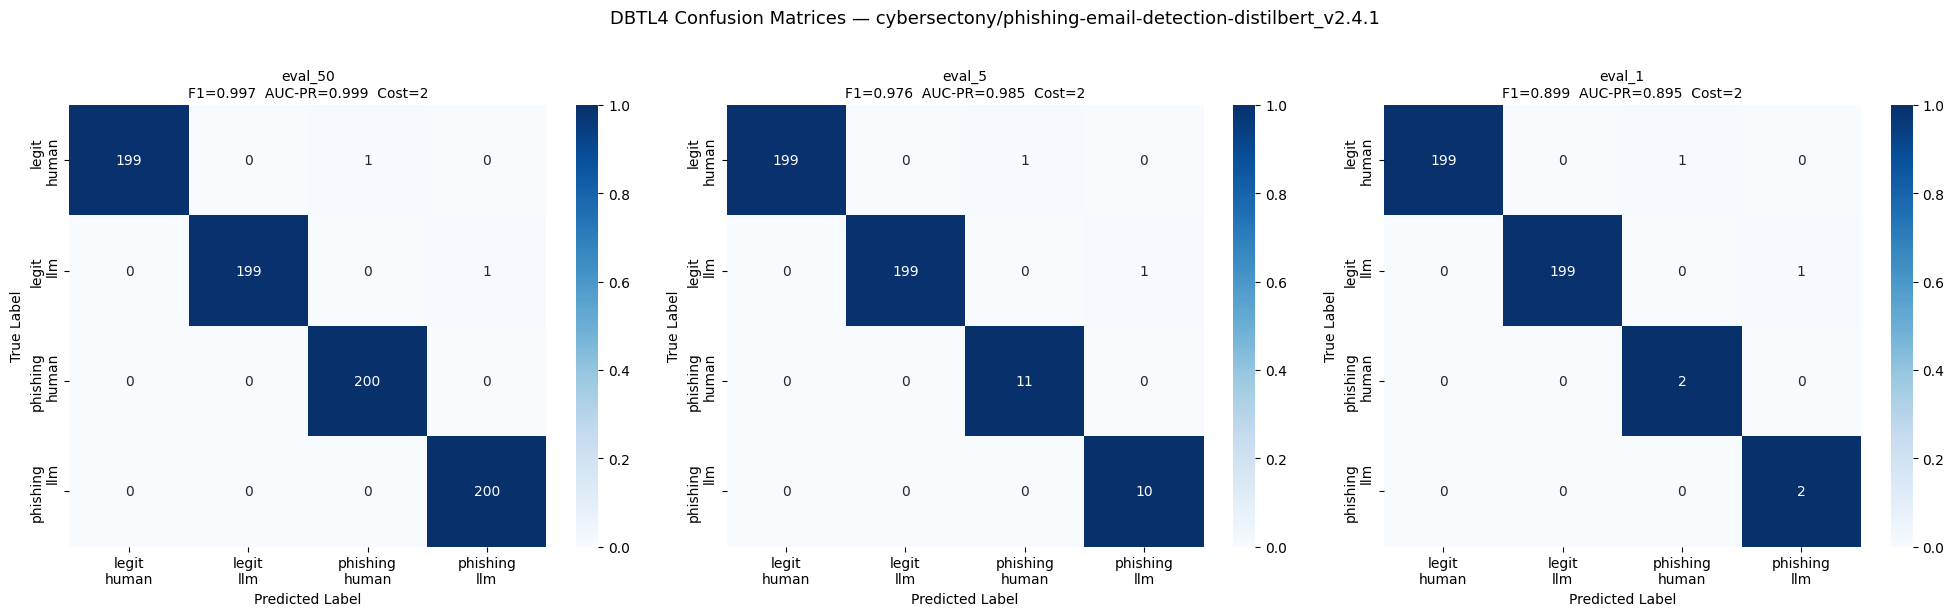

Saved to: /content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL4_Models_Results/confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
target_names_short = ['legit\nhuman', 'legit\nllm', 'phishing\nhuman', 'phishing\nllm']

for ax, (split_name, r) in zip(axes, eval_results.items()):
    cm = r['_cm']
    # Normalize by true label count for row-normalized view
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
        xticklabels=target_names_short,
        yticklabels=target_names_short,
        vmin=0, vmax=1
    )
    ax.set_title(
        f'{split_name}\nF1={r["F1_Score"]:.3f}  AUC-PR={r["AUC_PR"]:.3f}  Cost={r["Custom_Cost"]}',
        fontsize=10
    )
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle(f'DBTL4 Confusion Matrices — {MODEL_CHECKPOINT}', fontsize=13, y=1.02)
plt.tight_layout()

fig_path = os.path.join(save_path, 'confusion_matrices.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to: {fig_path}")

## 11.5. Binary-Collapsed Confusion Matrix

Collapses the 4-class predictions back to legit vs phishing (binary),
consistent with the custom cost function and the binary task in DBTL1–3.
Useful for directly comparing DBTL4 performance to prior iterations.

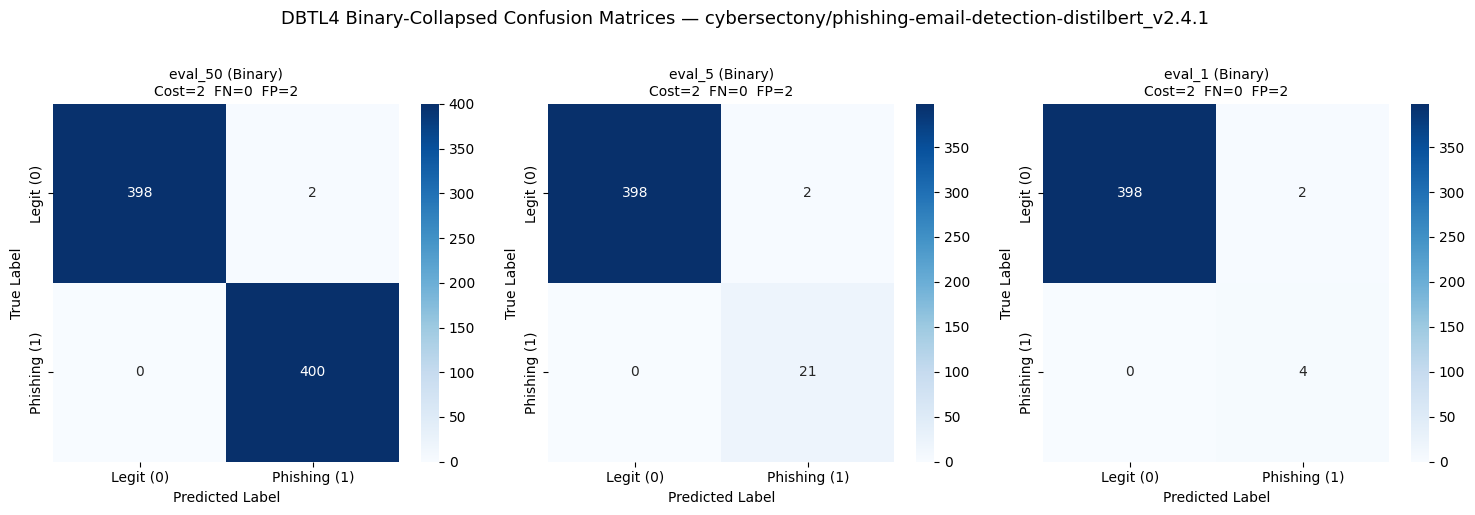

Saved to: /content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL4_Models_Results/confusion_matrices_binary.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (split_name, r) in zip(axes, eval_results.items()):
    true_bin = to_binary(r['_true'])
    pred_bin = to_binary(r['_pred'])
    cm_bin = confusion_matrix(true_bin, pred_bin)

    sns.heatmap(
        cm_bin, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Legit (0)', 'Phishing (1)'],
        yticklabels=['Legit (0)', 'Phishing (1)']
    )
    fn = int(np.sum((true_bin == 1) & (pred_bin == 0)))
    fp = int(np.sum((true_bin == 0) & (pred_bin == 1)))
    ax.set_title(
        f'{split_name} (Binary)\nCost={r["Custom_Cost"]}  FN={fn}  FP={fp}',
        fontsize=10
    )
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle(f'DBTL4 Binary-Collapsed Confusion Matrices — {MODEL_CHECKPOINT}', fontsize=13, y=1.02)
plt.tight_layout()

bin_fig_path = os.path.join(save_path, 'confusion_matrices_binary.png')
plt.savefig(bin_fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to: {bin_fig_path}")

# 12. Unified Pipeline: Multi-Class vs Binary Classification

This section re-runs the process to train a model on the multi-class task (`label_specific`) and another on the binary task (`label_generic`), then compares their performance on the `eval_1` dataset.

In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, DataCollatorWithPadding, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

# --- 12.1 Configuration ---
MODEL_CHECKPOINT = "cybersectony/phishing-email-detection-distilbert_v2.4.1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Reordered Label mappings per user request
SPECIFIC_MAPPING = {
    'human_legit': 0,
    'human_phishing': 1,
    'llm_legit': 2,
    'llm_phishing': 3
}
GENERIC_MAPPING = {'legit': 0, 'phishing': 1}

ID2SPECIFIC = {v: k for k, v in SPECIFIC_MAPPING.items()}
ID2GENERIC = {v: k for k, v in GENERIC_MAPPING.items()}

# Updated phishing classes indices based on new mapping (1 and 3)
PHISHING_SPECIFIC_CLASSES = {1, 3}

In [ ]:
# --- 12.2 Data Preparation Function ---
def prepare_task_data(df, label_col, mapping):
    out = df[['text', label_col]].copy()
    out['labels'] = out[label_col].map(mapping)
    out = out.dropna(subset=['labels'])
    out['labels'] = out['labels'].astype(int)
    return out[['text', 'labels']]

def create_task_datasets(label_col, mapping):
    df_tv_prep = prepare_task_data(df_dbtl4_train_valid, label_col, mapping)
    df_train, df_val = train_test_split(df_tv_prep, test_size=0.2, random_state=42, stratify=df_tv_prep['labels'])

    eval_50 = prepare_task_data(df_dbtl4_eval_50, label_col, mapping)
    eval_5  = prepare_task_data(df_dbtl4_eval_5, label_col, mapping)
    eval_1  = prepare_task_data(df_dbtl4_eval_1, label_col, mapping)

    dataset = DatasetDict({
        'train': Dataset.from_pandas(df_train, preserve_index=False),
        'validation': Dataset.from_pandas(df_val, preserve_index=False),
        'eval_50': Dataset.from_pandas(eval_50, preserve_index=False),
        'eval_5': Dataset.from_pandas(eval_5, preserve_index=False),
        'eval_1': Dataset.from_pandas(eval_1, preserve_index=False),
    })

    def tokenize_function(examples):
        return tokenizer(examples["text"], truncation=True)

    return dataset.map(tokenize_function, batched=True)

# Re-preparing datasets to ensure mapping is baked in
ds_multi = create_task_datasets('label_specific', SPECIFIC_MAPPING)
ds_binary = create_task_datasets('label_generic', GENERIC_MAPPING)
print("Datasets prepared with new label ordering.")

Map:   0%|          | 0/2560 [00:00<?, ? examples/s]

Map:   0%|          | 0/640 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/421 [00:00<?, ? examples/s]

Map:   0%|          | 0/404 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/640 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/421 [00:00<?, ? examples/s]

Map:   0%|          | 0/404 [00:00<?, ? examples/s]

Datasets prepared with new label ordering.


In [ ]:
import torch

# --- 12.3 Training Function ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1  = f1_metric.compute(predictions=predictions, references=labels, average='macro')
    return {**acc, **f1}

def train_model(task_name, dataset, num_labels, id2label, label2id):
    print(f"\n--- Training {task_name} Model ---")
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT, num_labels=num_labels, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True
    )

    training_args = TrainingArguments(
        output_dir=f'./results_{task_name}',
        learning_rate=2e-5,
        weight_decay=0.01,
        lr_scheduler_type='cosine',
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=6,
        eval_strategy='epoch',
        save_strategy='epoch',
        metric_for_best_model='f1',
        greater_is_better=True,
        load_best_model_at_end=True,
        save_total_limit=1,
        fp16=True,
        report_to='none',
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset['train'],
        eval_dataset=dataset['validation'],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    return trainer

# Clearing cache to ensure clean re-training with new labels
torch.cuda.empty_cache()

trainer_multi = train_model('multi_class', ds_multi, 4, ID2SPECIFIC, SPECIFIC_MAPPING)
trainer_binary = train_model('binary_class', ds_binary, 2, ID2GENERIC, GENERIC_MAPPING)


--- Training multi_class Model ---


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.088276,0.979688,0.979711
2,No log,0.046291,0.985938,0.985932
3,No log,0.044153,0.987500,0.987518
4,0.233019,0.044130,0.989062,0.989076
5,0.233019,0.049853,0.987500,0.987518
6,0.233019,0.048199,0.989062,0.989076


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [ ]:
# --- 12.4 Evaluation Function ---
def calculate_custom_cost(y_true_bin, y_pred_bin):
    fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    return int(50 * fn + fp)

def evaluate_trainer(trainer, dataset_dict, is_multi):
    results = {}
    for split in ['eval_50', 'eval_5', 'eval_1']:
        output = trainer.predict(dataset_dict[split])
        logits = output.predictions
        true_labels = output.label_ids
        proba = softmax(logits, axis=1)
        pred_labels = np.argmax(logits, axis=1)

        if is_multi:
            # New ordering indices: human_phishing=1, llm_phishing=3
            true_bin = np.array([1 if l in {1, 3} else 0 for l in true_labels])
            pred_bin = np.array([1 if l in {1, 3} else 0 for l in pred_labels])
            auc = roc_auc_score(true_labels, proba, multi_class='ovr', average='macro')
            pr_auc = average_precision_score(pd.get_dummies(true_labels), proba, average='macro')
        else:
            true_bin = true_labels
            pred_bin = pred_labels
            auc = roc_auc_score(true_labels, proba[:, 1])
            pr_auc = average_precision_score(true_labels, proba[:, 1])

        f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
        cost = calculate_custom_cost(true_bin, pred_bin)

        results[split] = {
            'F1_Score': f1, 'ROC_AUC': auc, 'AUC_PR': pr_auc, 'Custom_Cost': cost
        }
    return results

res_multi = evaluate_trainer(trainer_multi, ds_multi, is_multi=True)
res_binary = evaluate_trainer(trainer_binary, ds_binary, is_multi=False)
print("Evaluations updated with re-trained models.")

Evaluations updated with re-trained models.


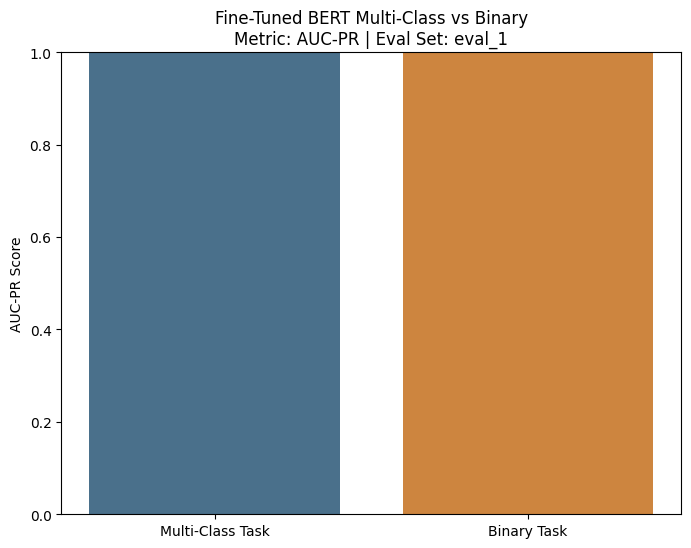

In [ ]:
# --- 12.5 Plotting AUC-PR for eval_1 ---
multi_pr_eval1 = res_multi['eval_1']['AUC_PR']
binary_pr_eval1 = res_binary['eval_1']['AUC_PR']

plt.figure(figsize=(8, 6))
# Using softer, darker shades: SteelBlue (#4A708B) and Peru/Dark Orange (#CD853F)
bars = plt.bar(['Multi-Class Task', 'Binary Task'], [multi_pr_eval1, binary_pr_eval1], color=['#4A708B', '#CD853F'])
plt.title('Fine-Tuned BERT Multi-Class vs Binary\nMetric: AUC-PR | Eval Set: eval_1')
plt.ylabel('AUC-PR Score')
plt.ylim(0, 1.0)

plt.show()

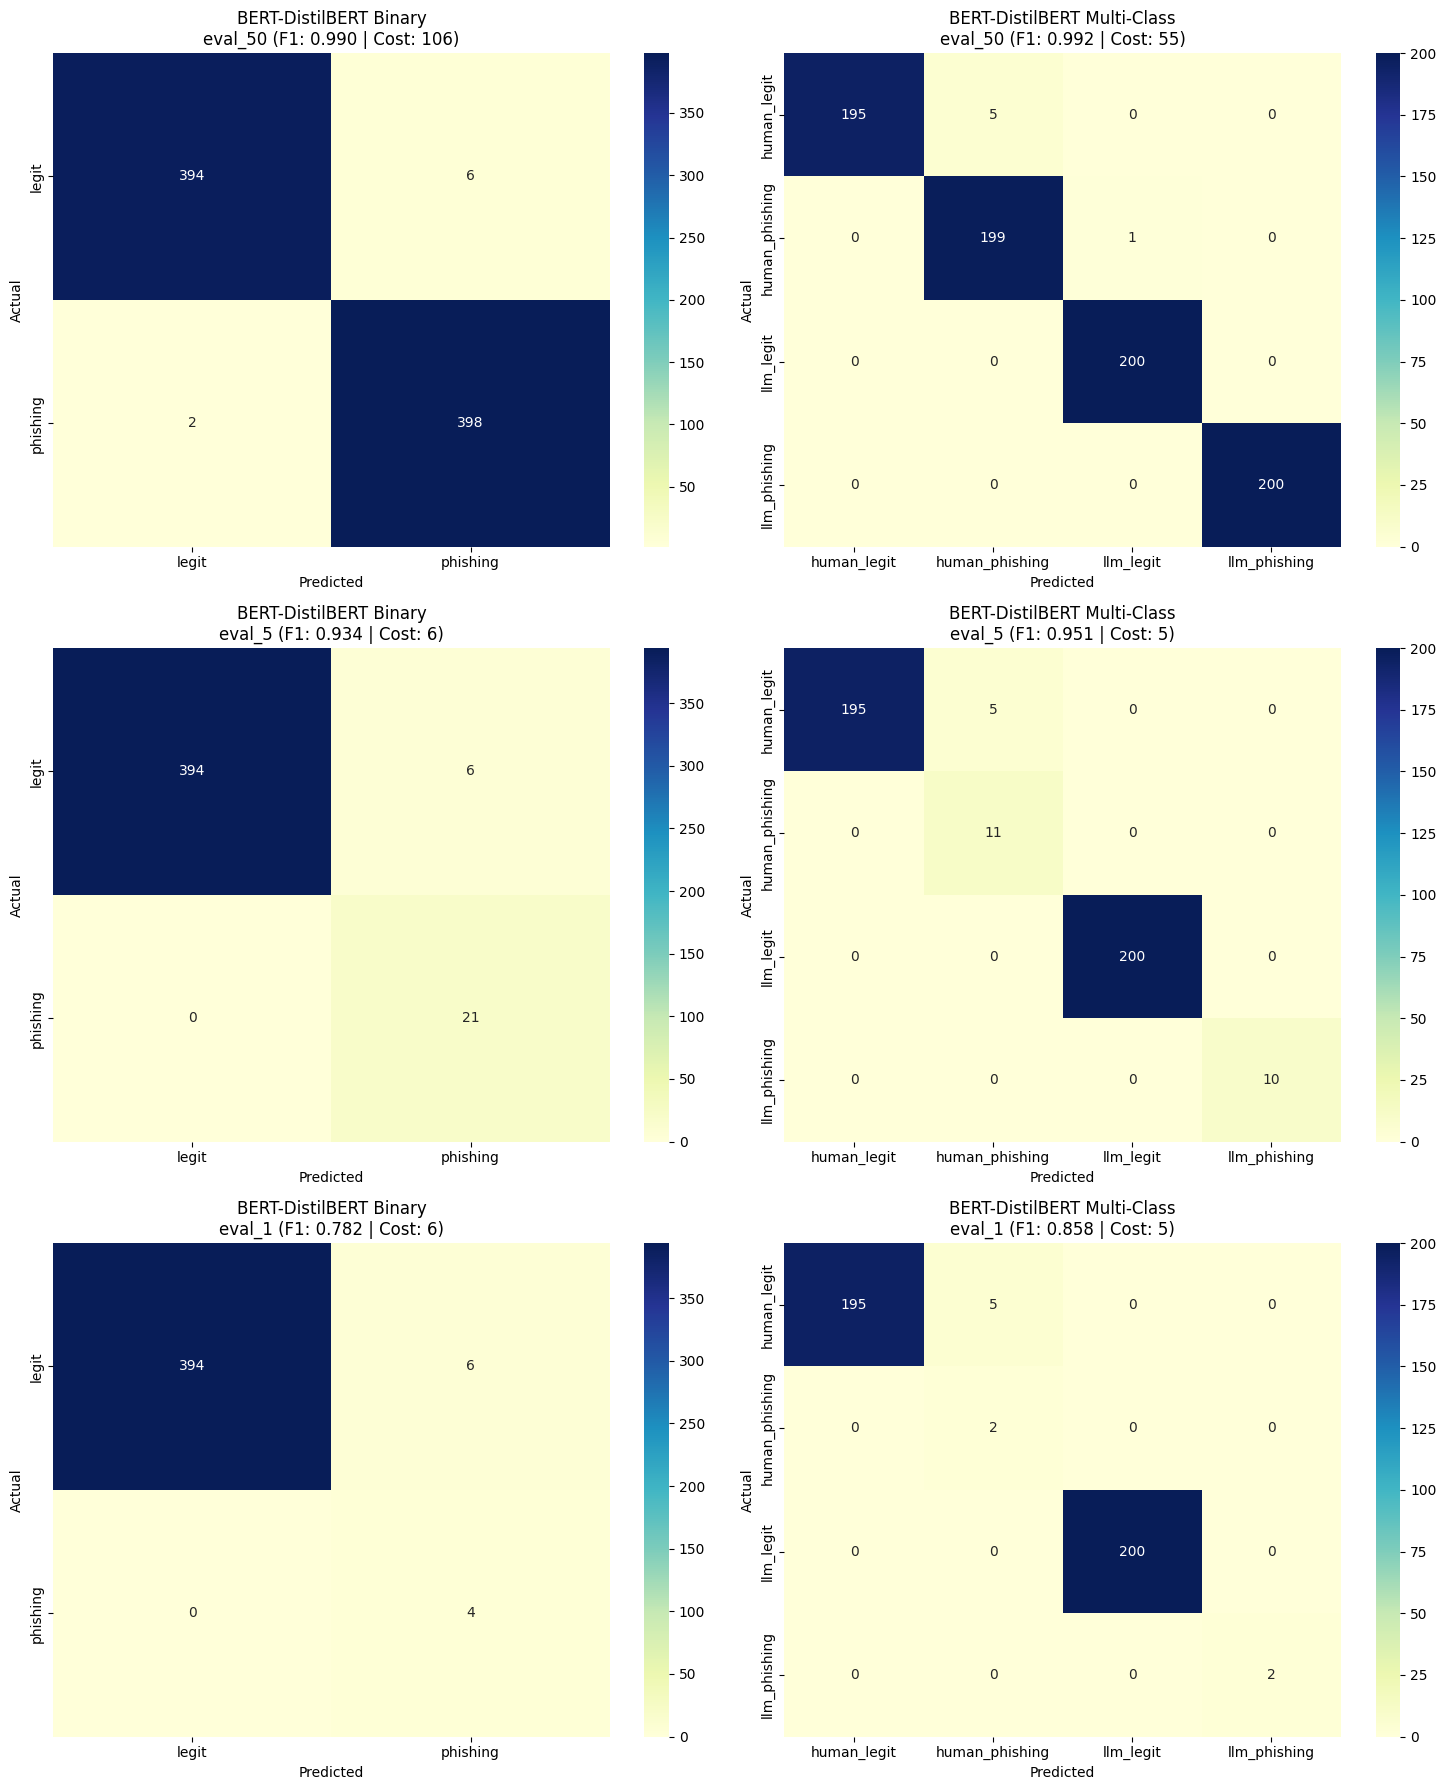

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

eval_sets = ['eval_50', 'eval_5', 'eval_1']
tasks = [('Binary', False), ('Multi-Class', True)]
model_name = 'BERT-DistilBERT'
data_name = 'DBTL4'
# Explicitly order labels by their assigned IDs (0-3)
class_names = [ID2SPECIFIC[i] for i in range(4)]
binary_names = [ID2GENERIC[i] for i in range(2)]

fig, axes = plt.subplots(3, 2, figsize=(15, 18))

for i, eval_set in enumerate(eval_sets):
    for j, (task_label, is_multi) in enumerate(tasks):
        ax = axes[i, j]

        current_trainer = trainer_multi if is_multi else trainer_binary
        current_ds = ds_multi if is_multi else ds_binary
        current_labels = class_names if is_multi else binary_names
        current_results = res_multi if is_multi else res_binary

        output = current_trainer.predict(current_ds[eval_set])
        # confusion_matrix uses labels=[0,1,2,3] to ensure the matrix matches our class_names order
        cm = confusion_matrix(output.label_ids, np.argmax(output.predictions, axis=1), labels=range(len(current_labels)))

        metrics = current_results[eval_set]
        f1_val = metrics['F1_Score']
        cost_val = metrics['Custom_Cost']

        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=ax,
                    xticklabels=current_labels,
                    yticklabels=current_labels)

        title_suffix = f"F1: {f1_val:.3f} | Cost: {cost_val}"
        ax.set_title(f"{model_name} {task_label}\n{eval_set} ({title_suffix})")
        ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()